# Function Predictor — Experimentos com NEAT

**Objetivo:** Evoluir redes neurais que prevejam o próximo valor em uma sequência gerada por uma função matemática desconhecida.

**Interface da rede:**
- **Entrada:** janela de `WINDOW_SIZE` valores consecutivos normalizados `[y_i, ..., y_{i+W-1}]`
- **Saída:** predição do próximo valor `ŷ_{i+W}`

**Famílias suportadas:** polinômios (linear, quadrática, cúbica, quártica), exponencial, logarítmica, seno, cosseno.

**Fitness:** `1 / (1 + MSE)` — varia de 0 (péssimo) a 1 (perfeito).

In [1]:
import sys
import os

# Adiciona src/ ao path para importar os módulos do projeto
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import numpy as np
import matplotlib.pyplot as plt
import neat

from generators.polynomial import POLYNOMIAL_FUNCTIONS
from generators.exponential import EXPONENTIAL_FUNCTIONS
from generators.logarithmic import LOGARITHMIC_FUNCTIONS
from generators.trigonometric import TRIGONOMETRIC_FUNCTIONS
from datasets.sequence_builder import generate_x_values, generate_random_functions, build_sequences
from neat_core.evaluator import make_eval_function, WINDOW_SIZE, evaluate_genome
from neat_core.trainer import load_config, train, save_genome, load_genome
from neat_core import visualizer as viz

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

print(f"neat-python versão : {neat.__version__}")
print(f"WINDOW_SIZE        : {WINDOW_SIZE}  (deve coincidir com num_inputs em neat.cfg)")

neat-python versão : 2.0.0
WINDOW_SIZE        : 10  (deve coincidir com num_inputs em neat.cfg)


---
## 1. Geração de Dados de Treino

Geramos sequências de múltiplas famílias de funções com parâmetros aleatórios.  
O NEAT verá **janelas de `WINDOW_SIZE` valores consecutivos** e tentará prever o próximo.

**Parâmetros importantes:**
- `N_PER_TYPE` — quantas sequências de cada tipo de função gerar
- `N_POINTS` — quantos pontos cada sequência tem
- `PARAM_RANGES` — faixas de parâmetros de cada função (controla a dificuldade)

In [2]:
ALL_DEFINITIONS = (
    POLYNOMIAL_FUNCTIONS
    + EXPONENTIAL_FUNCTIONS
    + LOGARITHMIC_FUNCTIONS
    + TRIGONOMETRIC_FUNCTIONS
)

# Faixas de parâmetros — ajuste para variar a dificuldade
PARAM_RANGES = {
    "linear":      {"a": (-3.0, 3.0), "b": (-5.0, 5.0)},
    "quadratic":   {"a": (-0.5, 0.5), "b": (-3.0, 3.0), "c": (-5.0, 5.0)},
    "cubic":       {"a": (-0.1, 0.1), "b": (-0.5, 0.5), "c": (-2.0, 2.0), "d": (-5.0, 5.0)},
    "quartic":     {"a": (-0.02, 0.02), "b": (-0.1, 0.1), "c": (-0.5, 0.5), "d": (-2.0, 2.0), "e": (-5.0, 5.0)},
    "exponential": {"a": (-2.0, 2.0), "b": (-0.3, 0.3), "c": (-3.0, 3.0)},
    "logarithmic": {"a": (-3.0, 3.0), "b": (0.5, 2.0), "c": (1.0, 5.0), "d": (-3.0, 3.0)},
    "sine":        {"a": (-3.0, 3.0), "b": (0.1, 1.0), "c": (-3.14159, 3.14159), "d": (-3.0, 3.0)},
    "cosine":      {"a": (-3.0, 3.0), "b": (0.1, 1.0), "c": (-3.14159, 3.14159), "d": (-3.0, 3.0)},
}

print("Famílias de funções:", [d.name for d in ALL_DEFINITIONS])

Famílias de funções: ['linear', 'quadratic', 'cubic', 'quartic', 'exponential', 'logarithmic', 'sine', 'cosine']


In [3]:
RNG_SEED = 42
N_PER_TYPE = 25   # sequências por tipo de função
N_POINTS   = 40   # pontos por sequência

rng = np.random.default_rng(RNG_SEED)

# Gera N_PER_TYPE sequências de cada tipo (distribuição balanceada)
train_functions = []
for defn in ALL_DEFINITIONS:
    instances = generate_random_functions(
        [defn],
        {defn.name: PARAM_RANGES[defn.name]},
        N_PER_TYPE,
        rng,
    )
    train_functions.extend(instances)

x_values = generate_x_values(N_POINTS)
train_sequences = build_sequences(train_functions, x_values)

# Remove sequências com valores inválidos (NaN/Inf podem surgir em exp/log extremos)
train_sequences = [s for s in train_sequences if np.isfinite(s.y_values).all()]

counts = {}
for s in train_sequences:
    counts[s.category] = counts.get(s.category, 0) + 1

print(f"Sequências de treino válidas : {len(train_sequences)}")
print(f"Por categoria                : {counts}")
print(f"Predições totais de treino   : {len(train_sequences) * (N_POINTS - WINDOW_SIZE):,}")

Sequências de treino válidas : 200
Por categoria                : {'polynomial': 100, 'exponential': 25, 'logarithmic': 25, 'trigonometric': 50}
Predições totais de treino   : 6,000


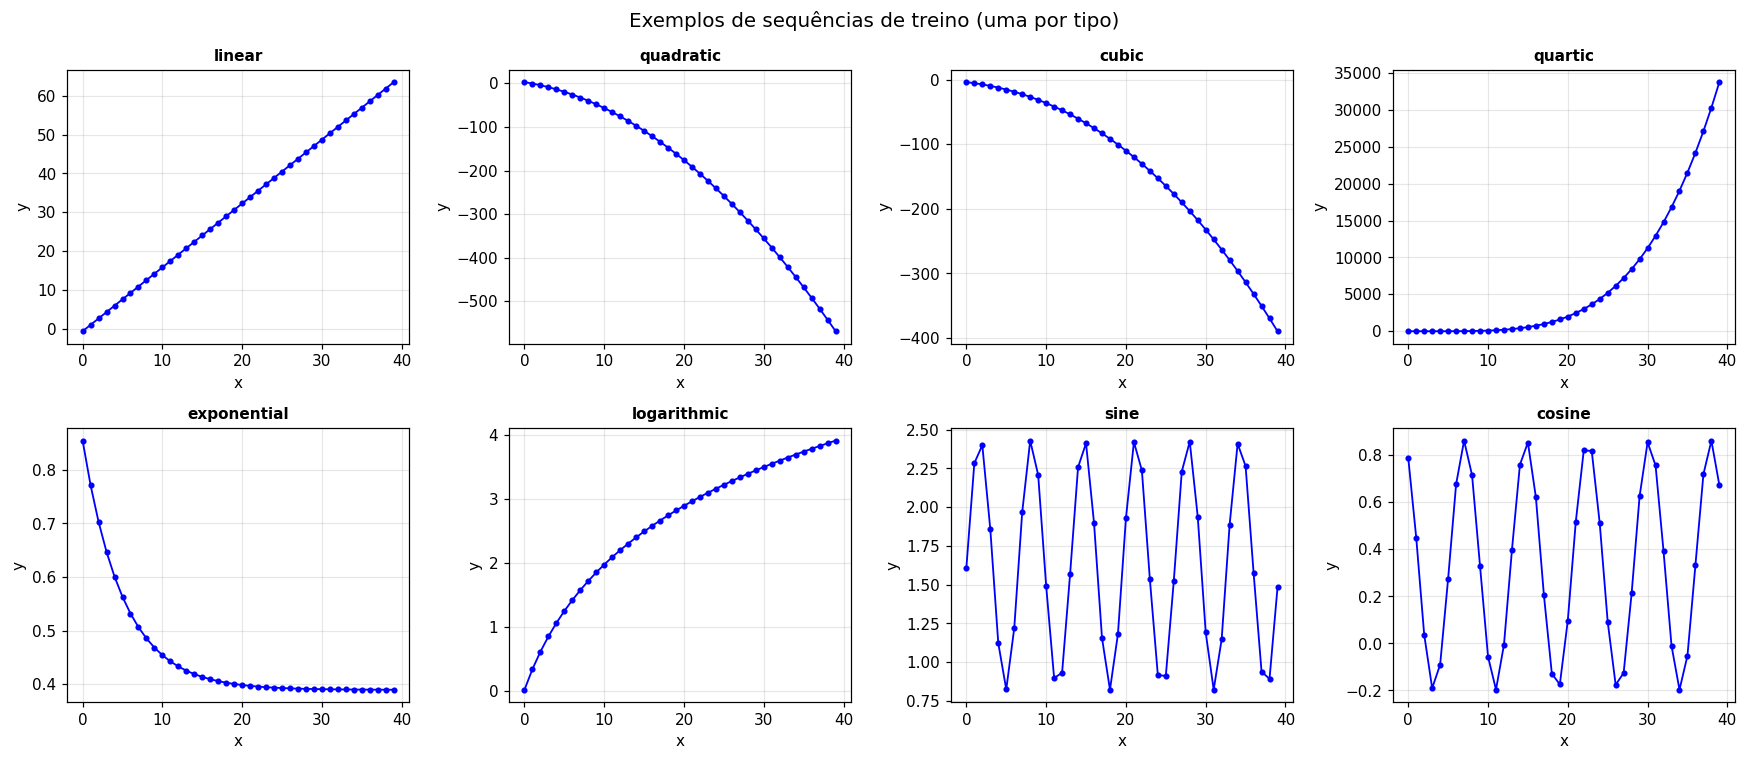

In [4]:
# Visualiza um exemplo de cada tipo de função
shown: dict = {}
for s in train_sequences:
    if s.function_name not in shown:
        shown[s.function_name] = s

n_plots = len(shown)
cols = 4
rows = (n_plots + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.5))
axes = axes.flatten()

for ax, (name, seq) in zip(axes, shown.items()):
    ax.plot(seq.x_values, seq.y_values, "b-o", markersize=3, linewidth=1.2)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle("Exemplos de sequências de treino (uma por tipo)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Treino com NEAT

O NEAT começa com redes **mínimas** (só inputs e outputs) e vai crescendo ao longo das gerações:
- **Mutação estrutural:** adiciona nós e conexões
- **Mutação de parâmetros:** altera pesos, biases e funções de ativação
- **Especiação:** isola inovações em nichos para que tenham tempo de amadurecer

**Parâmetros de treino:** edite `config/neat.cfg` para ajustar.  
Para regenerar o config com todos os defaults documentados:
```bash
python scripts/generate_config.py --output config/neat.cfg
```

In [5]:
N_GENERATIONS = 50  # Aumente para experimentos mais longos

eval_fn = make_eval_function(train_sequences)

winner, stats, config = train(
    eval_function=eval_fn,
    config_path="config/neat.cfg",
    n_generations=N_GENERATIONS,
    checkpoint_dir="checkpoints",
    checkpoint_interval=10,
)

print(f"\n{'='*50}")
print(f"Melhor fitness   : {winner.fitness:.4f}")
print(f"Nós              : {len(winner.nodes)}")
print(f"Conexões totais  : {len(winner.connections)}")
conn_enabled = sum(1 for c in winner.connections.values() if c.enabled)
print(f"Conexões ativas  : {conn_enabled}")


 ****** Running generation 0 ****** 

Population's average fitness: 0.39329 stdev: 0.12104
Best fitness: 0.67645 - size: (1, 10) - species 1 - id 143
Average adjusted fitness: 0.158
Mean genetic distance 1.056, standard deviation 0.341
Population of 200 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0   200      0.676    0.158     0
Total extinctions: 0
Generation time: 5.268 sec

 ****** Running generation 1 ****** 

Population's average fitness: 0.52349 stdev: 0.11375
Best fitness: 0.74203 - size: (1, 9) - species 1 - id 278
Average adjusted fitness: 0.316
Mean genetic distance 1.170, standard deviation 0.329
Population of 200 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    1   200      0.742    0.316     0
Total extinctions: 0
Generation time: 5.116 sec (5.192 average)

 ****** Running generation 2

---
## 3. Análise do Treino

- **Gráfico de fitness:** mostra como o melhor e o fitness médio evoluíram
- **Gráfico de espécies:** mostra quantas espécies surgiram e como cresceram

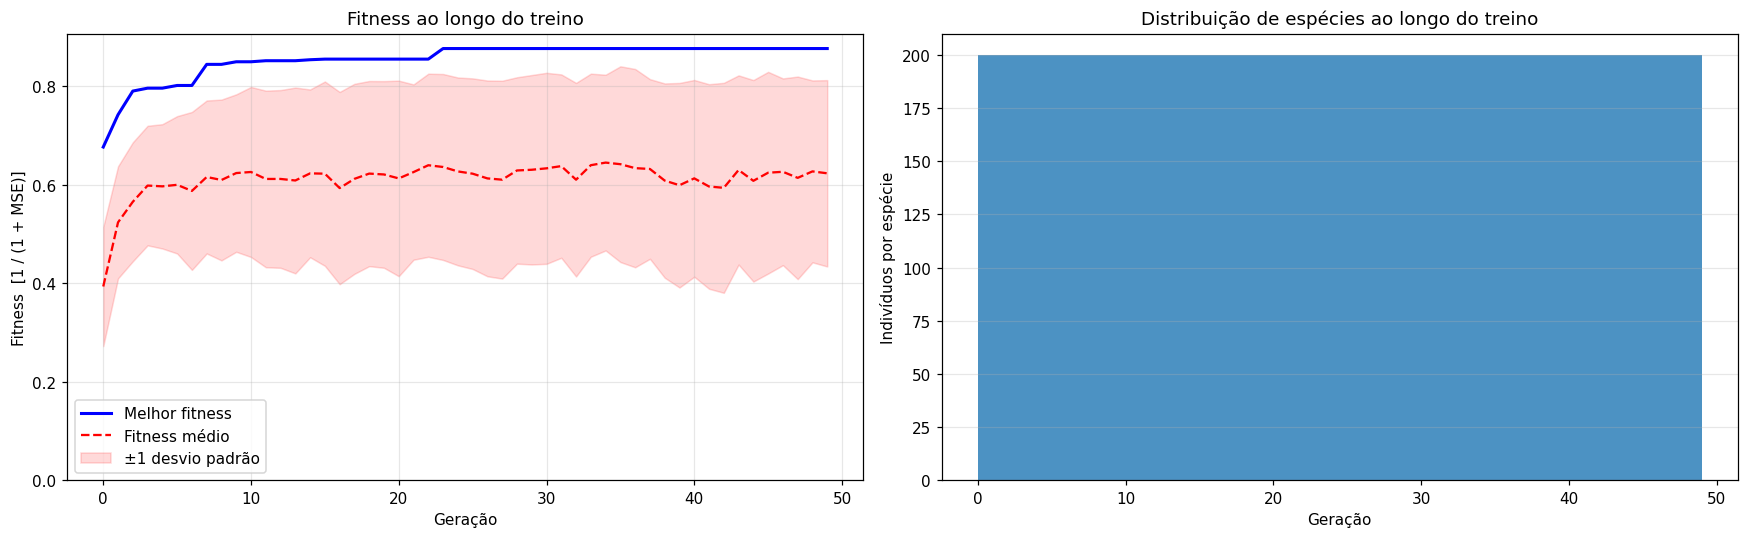

Fitness inicial : 0.6765
Fitness final   : 0.8764
Melhoria total  : +0.2000


In [6]:
fig = viz.plot_training_summary(stats)
plt.show()

best_history = [g.fitness for g in stats.most_fit_genomes]
print(f"Fitness inicial : {best_history[0]:.4f}")
print(f"Fitness final   : {best_history[-1]:.4f}")
print(f"Melhoria total  : {best_history[-1] - best_history[0]:+.4f}")

---
## 4. Avaliação em Dados de Teste

Testamos o vencedor em sequências **nunca vistas durante o treino** (seed diferente).  
Isso mede a capacidade de generalização, não apenas memorização.

In [7]:
rng_test = np.random.default_rng(999)
N_TEST_PER_TYPE = 5

test_functions = []
for defn in ALL_DEFINITIONS:
    instances = generate_random_functions(
        [defn],
        {defn.name: PARAM_RANGES[defn.name]},
        N_TEST_PER_TYPE,
        rng_test,
    )
    test_functions.extend(instances)

test_sequences = build_sequences(test_functions, generate_x_values(N_POINTS))
test_sequences = [s for s in test_sequences if np.isfinite(s.y_values).all()]

test_fitnesses: dict = {}
for s in test_sequences:
    f = evaluate_genome(winner, config, [s])
    test_fitnesses.setdefault(s.category, []).append(f)

print(f"{'Categoria':<15}  {'Média':>8}  {'Desvio':>8}  {'Min':>8}  {'Max':>8}")
print("-" * 55)
for cat, fitnesses in sorted(test_fitnesses.items()):
    arr = np.array(fitnesses)
    print(f"{cat:<15}  {arr.mean():>8.4f}  {arr.std():>8.4f}  {arr.min():>8.4f}  {arr.max():>8.4f}")

Categoria           Média    Desvio       Min       Max
-------------------------------------------------------
exponential        0.8789    0.1266    0.6712    0.9852
logarithmic        0.9842    0.0043    0.9790    0.9893
polynomial         0.8608    0.0588    0.7766    0.9404
trigonometric      0.9201    0.0128    0.8908    0.9339


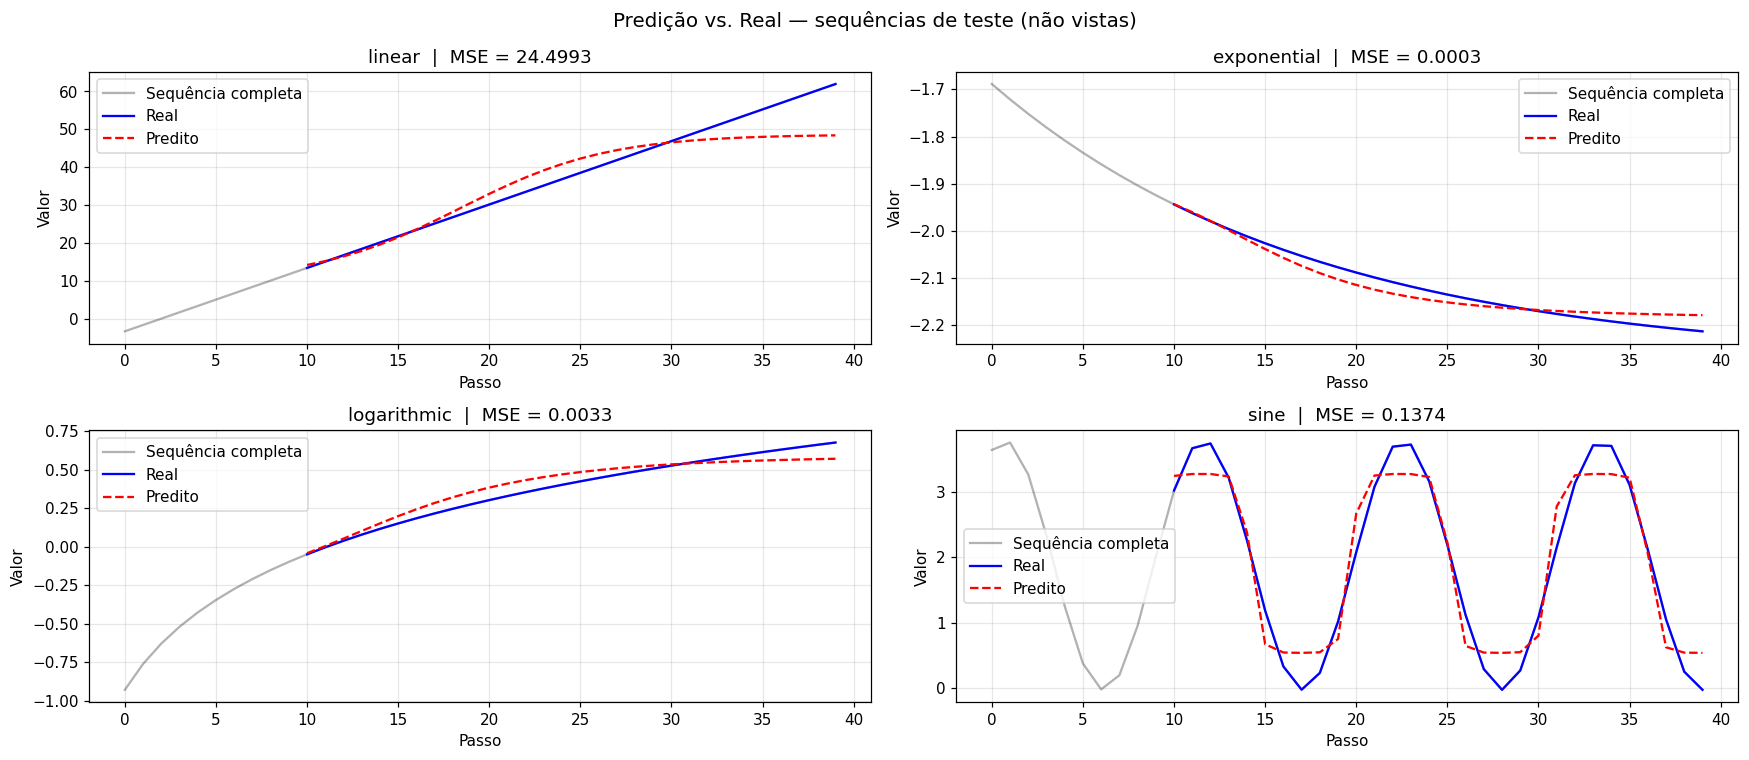

In [8]:
winner_net = neat.nn.FeedForwardNetwork.create(winner, config)

shown_cats: set = set()
examples = []
for s in test_sequences:
    if s.category not in shown_cats:
        examples.append(s)
        shown_cats.add(s.category)

cols = 2
rows = (len(examples) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.5))
axes = axes.flatten()

for ax, s in zip(axes, examples):
    viz.plot_prediction(winner_net, s, ax=ax)

for ax in axes[len(examples):]:
    ax.set_visible(False)

plt.suptitle("Predição vs. Real — sequências de teste (não vistas)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Extrapolação Além dos Dados Conhecidos

A rede usa suas próprias predições como entrada para continuar a sequência sem ver novos valores reais.  
O erro tende a acumular a cada passo — quanto mais longe, menos confiável.

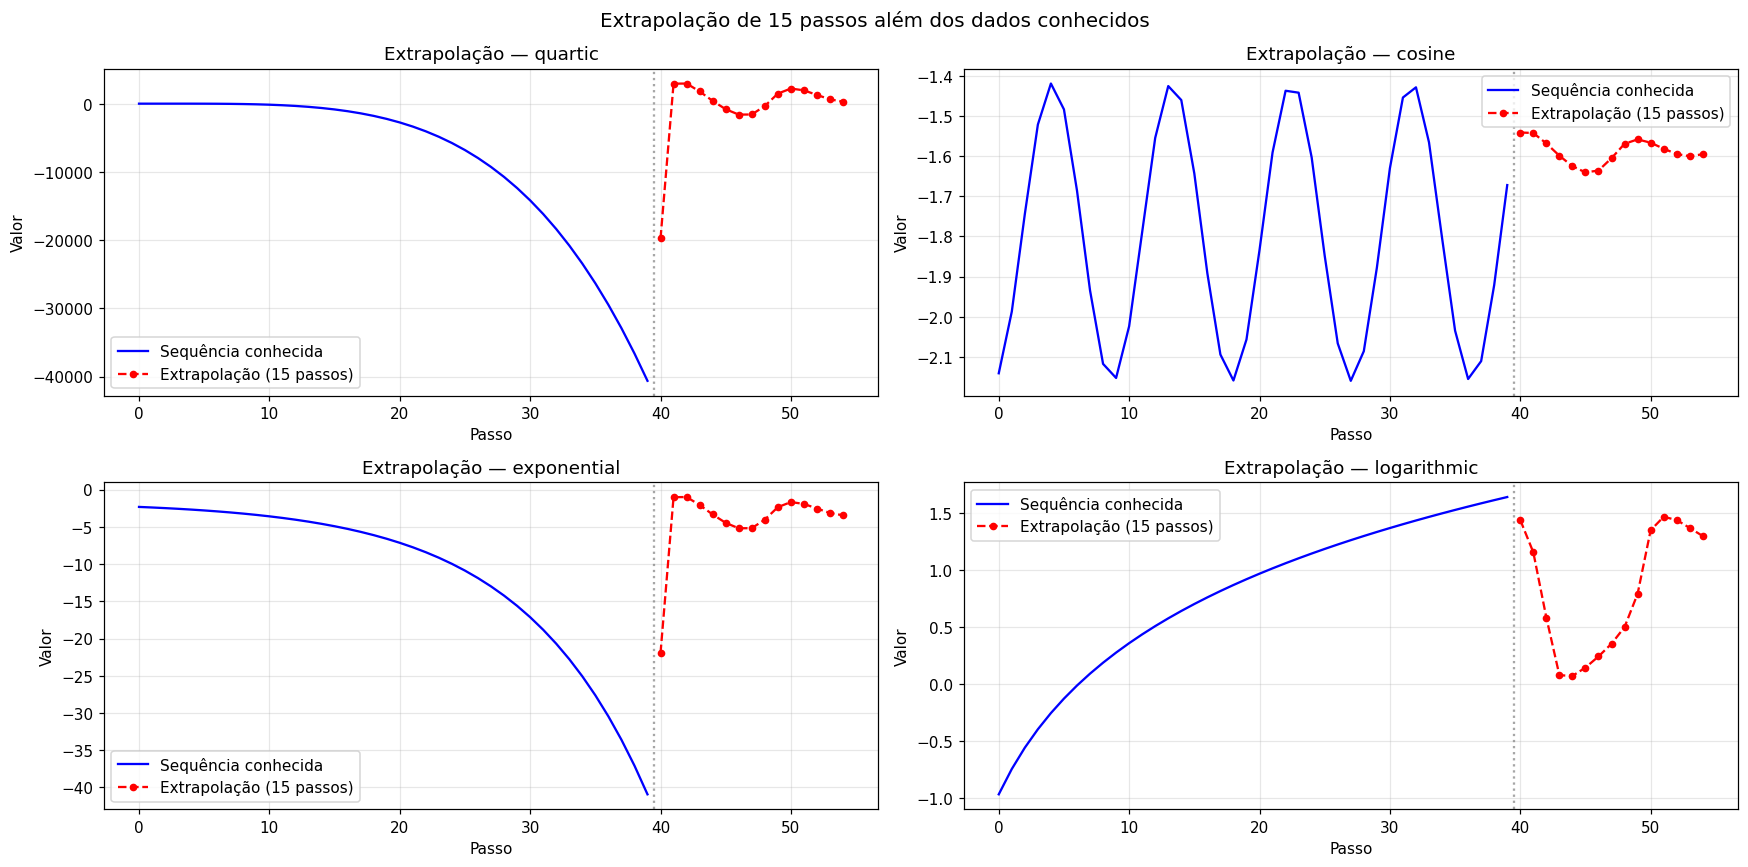

In [9]:
N_EXTRA = 15

target_cats = ["polynomial", "trigonometric", "exponential", "logarithmic"]
extra_examples = {s.category: s for s in test_sequences if s.category in target_cats}

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for ax, cat in zip(axes, target_cats):
    if cat in extra_examples:
        viz.plot_extrapolation(winner_net, extra_examples[cat], n_extra=N_EXTRA, ax=ax)

plt.suptitle(f"Extrapolação de {N_EXTRA} passos além dos dados conhecidos", fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Topologia da Rede Evoluída

O NEAT começa com a rede mínima e adiciona nós/conexões conforme necessário.  
- **Azul** = peso positivo | **Vermelho** = peso negativo | **Cinza tracejado** = desabilitada  
- A espessura das setas reflete a magnitude do peso.

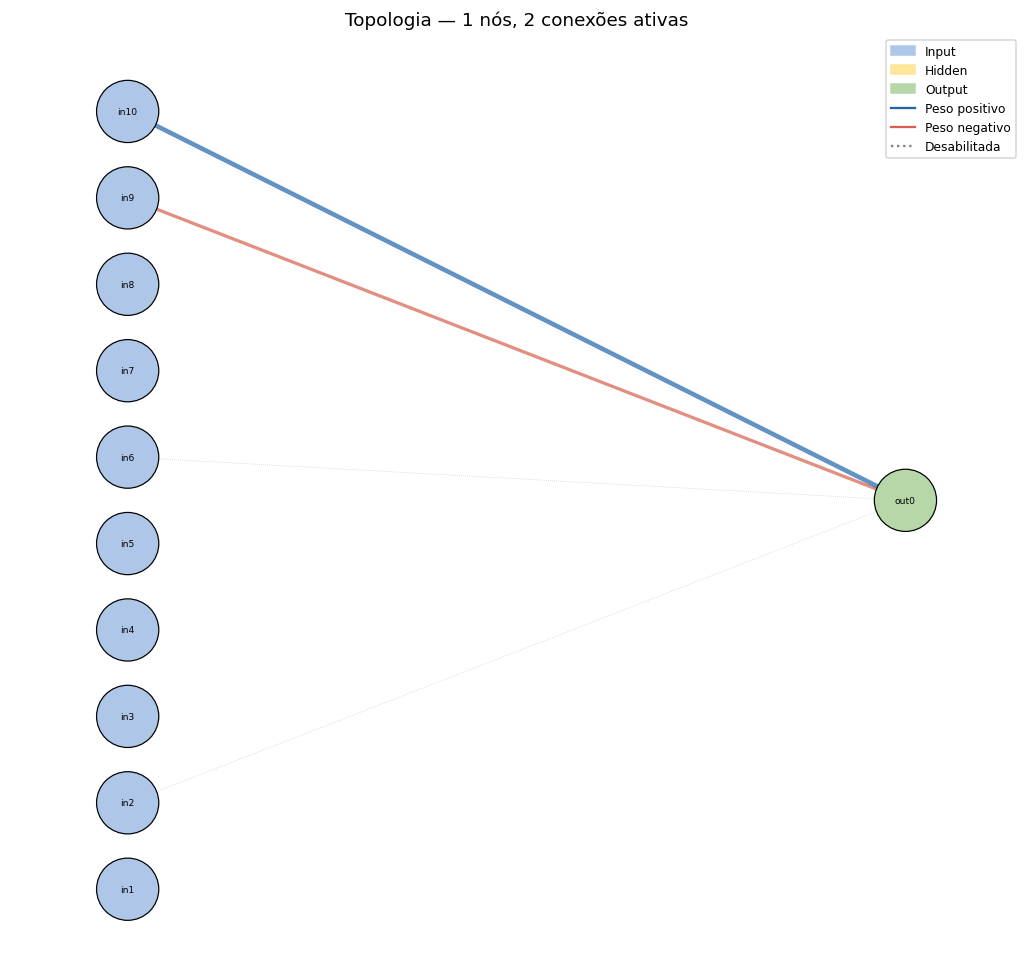

Inputs  : 10
Hidden  : 0
Outputs : 1
Conexões ativas   : 2
Conexões disabled : 2


In [10]:
fig, ax = plt.subplots(figsize=(13, 9))
viz.draw_network(config, winner, ax=ax)
plt.tight_layout()
plt.show()

hidden_keys = [
    k for k in winner.nodes
    if k not in config.genome_config.input_keys
    and k not in config.genome_config.output_keys
]
print(f"Inputs  : {len(config.genome_config.input_keys)}")
print(f"Hidden  : {len(hidden_keys)}")
print(f"Outputs : {len(config.genome_config.output_keys)}")
print(f"Conexões ativas   : {sum(1 for c in winner.connections.values() if c.enabled)}")
print(f"Conexões disabled : {sum(1 for c in winner.connections.values() if not c.enabled)}")

---
## 7. Salvar / Carregar Genoma

In [11]:
save_genome(winner, "models/winner.pkl")
print("Genoma salvo em models/winner.pkl")

# Para carregar em outra sessão:
# config = load_config("config/neat.cfg")
# winner_loaded = load_genome("models/winner.pkl")
# net = neat.nn.FeedForwardNetwork.create(winner_loaded, config)

Genoma salvo em models/winner.pkl
